In [1]:
import config, utils
import pandas as pd
import json
import models.datacenter
import models.scheduler
import models.job

## Problem setup

### Load jobs from spark traces

In [2]:
exp_traces_path = f"data/{config.d_i}-{config.d_f}/traces.csv"
traces_df = pd.read_csv(exp_traces_path)

In [3]:

jobs = {
    index : 
    models.job.Job(
        release_time=utils.str_to_date(trace.release_time), 
        release_location=trace.release_location, 
        release_platform=trace.platform.lower(), 
        runtime=trace.runtime_sec,
        n_nodes = trace.n_nodes,
        VM_instance = trace.VM_instance,
    )
    for index, trace in traces_df.iterrows() if index < 30
}

### Load datacenters

In [4]:
datacenters = {
    index: models.datacenter.Datacenter(
        provider=dc_name.split(".")[0].split("_")[0],
        location=dc_name.split(".")[0].split("_")[1],
        data=json.load(open(config.in_path+dc_name+".json", "r"))
    )
    for index, dc_name in enumerate(config.datacenter_list)
    
}

### Generate VMs

In [5]:
vm_instance_names= {
    "aws": 
    [
        "c4.large", 
        "m4.large",
        "r4.large",
        "c4.xlarge", 
        "m4.xlarge",
        "r4.xlarge"
    ],
    "gcp": 
    [
        "n2_highcpu-8",
        "n2_standard-8",
        "n2_highmem-8",
        "n2_highmem-4",
        "n2_highcpu-32",
        "n2-standard-4"
    ]
}

In [6]:
# For this instace we generate 8 VM for each dc. --> 8*4 =32 VMs since we have 4 datacenters and 30 jobs to allocate
vm_instances = {}
i=0
for dc in datacenters.values():
    for vm_name in vm_instance_names[dc.provider] + vm_instance_names[dc.provider][:2]:
        vm = dc.add_vm_instance(vm_name = vm_name, n_nodes = 1)
        vm_instances[i]=vm
        i+=1

In [7]:
print("Problem recap:")
print("Jobs loaded: ", len(jobs))
print("Datacenters loaded: ", len(datacenters))
print("VM instances loaded: ", len(vm_instances))

Problem recap:
Jobs loaded:  30
Datacenters loaded:  4
VM instances loaded:  32


### Initilize Scheduler

In [8]:

scheduler = models.scheduler.Scheduler(
    datacenters=datacenters,
    jobs=jobs,
    vm_instances=vm_instances
    
)

In [ ]:

from models.objectives import compute_overall_carbon, compute_overall_water, compute_overall_land_use, compute_overall_linear
objectives = {
    "carbon_opt": compute_overall_carbon,
    "water_opt": compute_overall_water,
    "land_use_opt": compute_overall_land_use,
    "linear_opt": compute_overall_linear,
    "geo_baseline": None
}

#### Compute schedule for all algorithms

In [ ]:
footprints = {
    "carbon_opt": scheduler.MILP_schedule(objectives["carbon_opt"]),
    "water_opt": scheduler.MILP_schedule(objectives["water_opt"]),
    "land_use_opt": scheduler.MILP_schedule(objectives["land_use_opt"]),
    "linear_opt": scheduler.MILP_schedule(objectives["linear_opt"]),
    "geo_baseline": scheduler.geo_baseline_schedule()
}


Set parameter Username
Academic license - for non-commercial use only - expires 2026-02-21
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 23.3.0 23D60)

CPU model: Apple M1 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 62 rows, 960 columns and 1920 nonzeros
Model fingerprint: 0x3d6101ac
Variable types: 0 continuous, 960 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-01, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 479.3857676
Presolve time: 0.00s
Presolved: 62 rows, 960 columns, 1920 nonzeros
Variable types: 0 continuous, 960 integer (960 binary)

Root relaxation: objective 1.887081e+02, 206 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*   

In [11]:
timestamps = utils.get_timestamps(
    init_time=config.dt_i,
    final_time=config.dt_f,
    step_duration=config.step
)

# Results

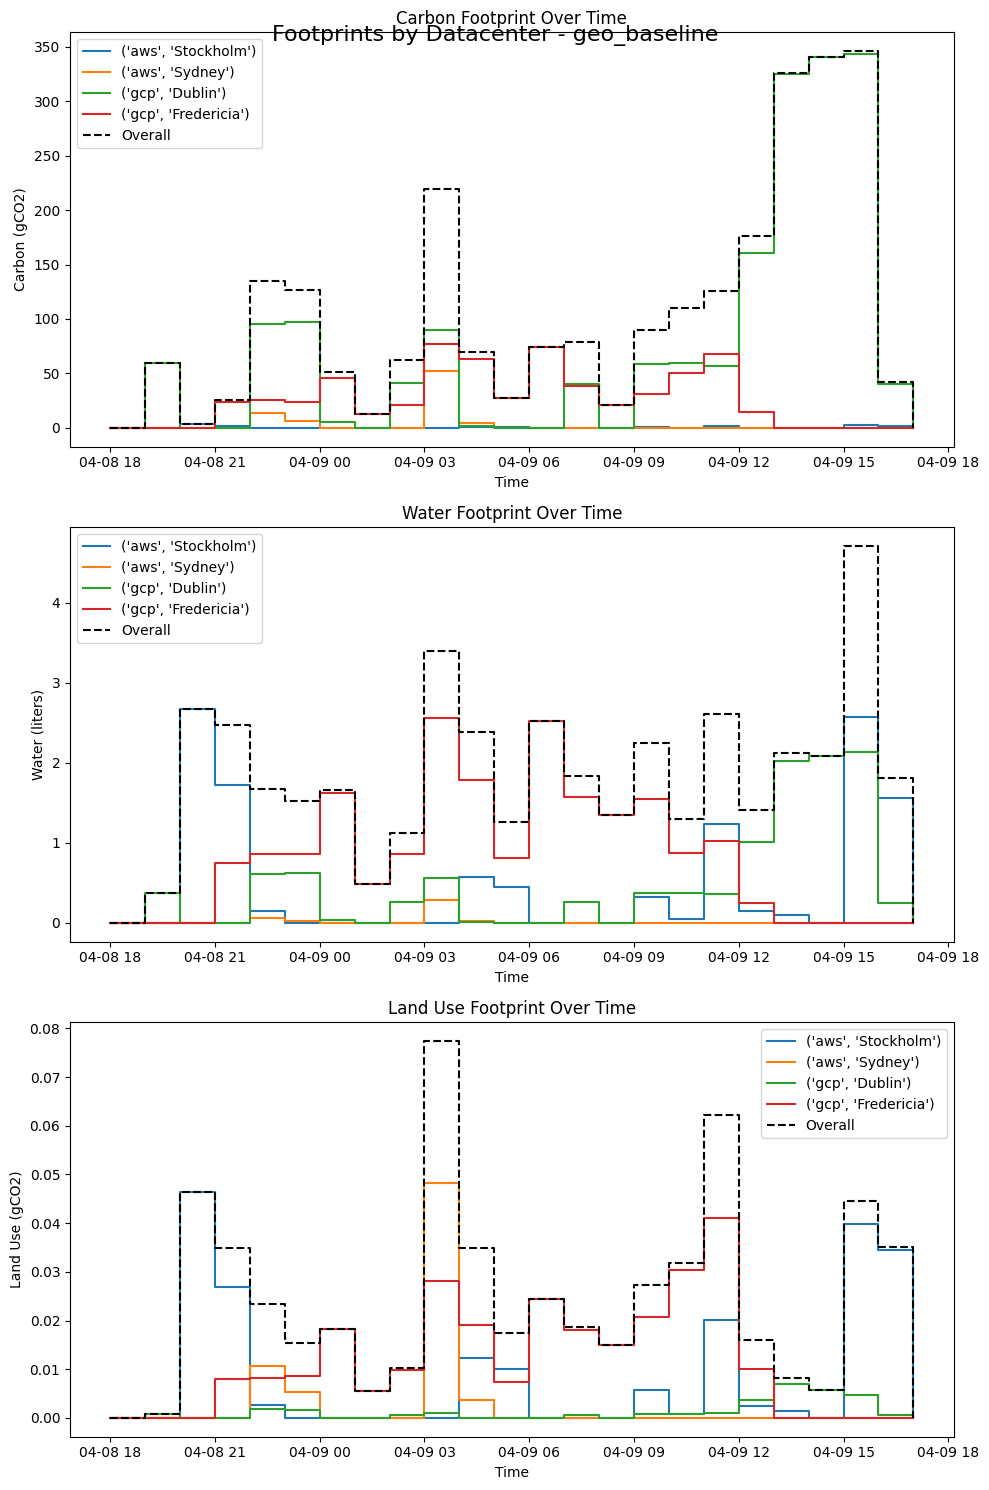

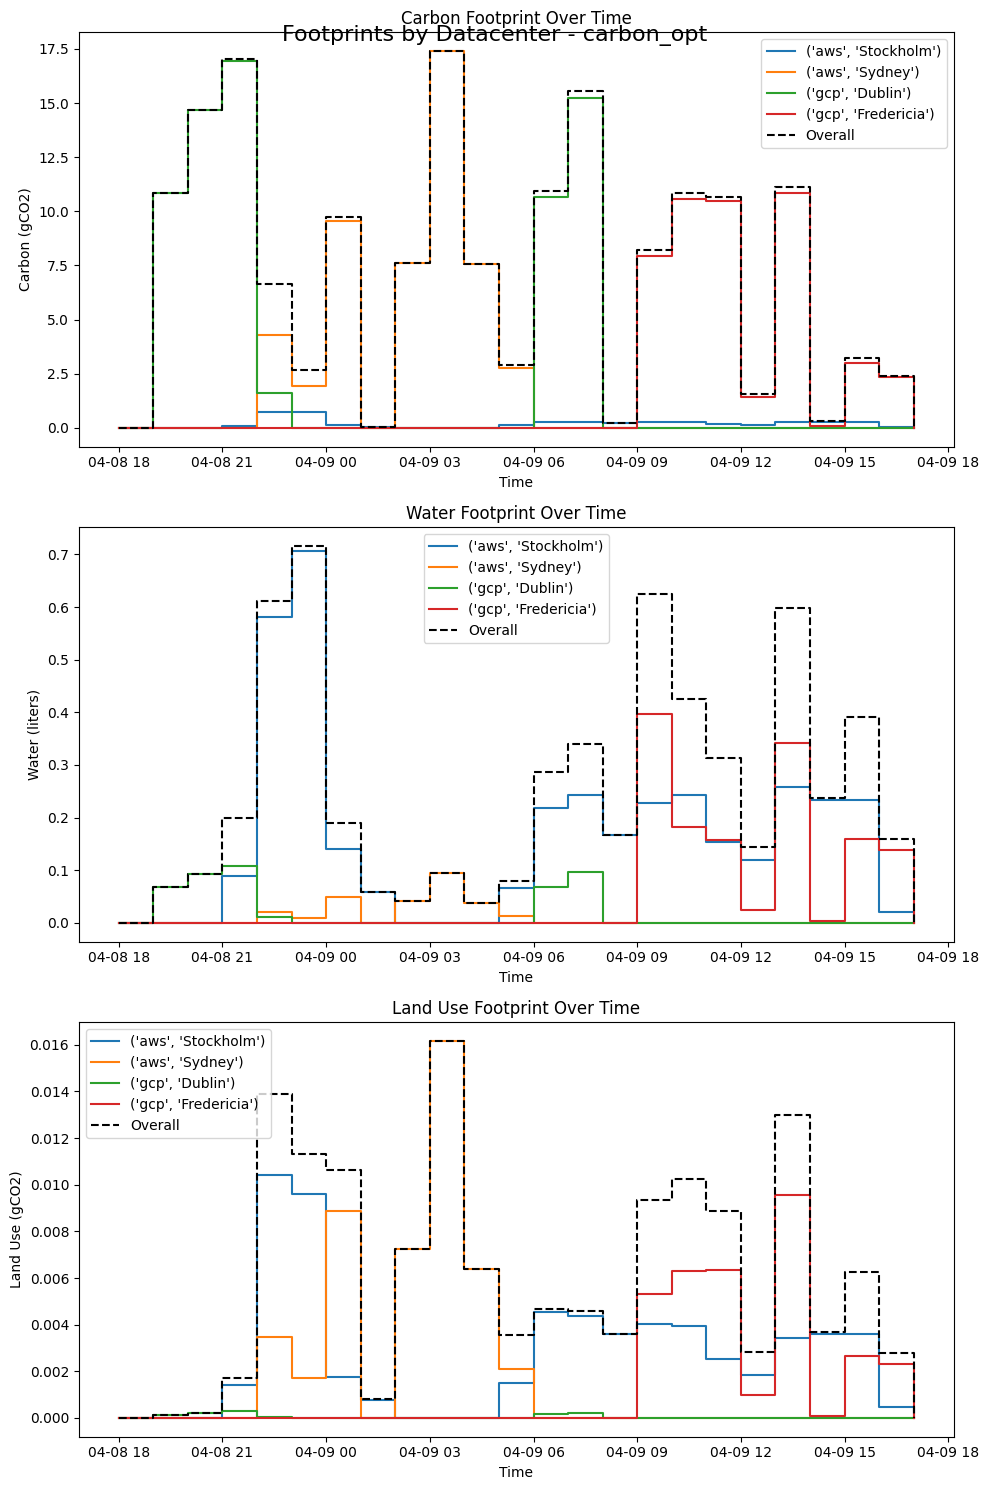

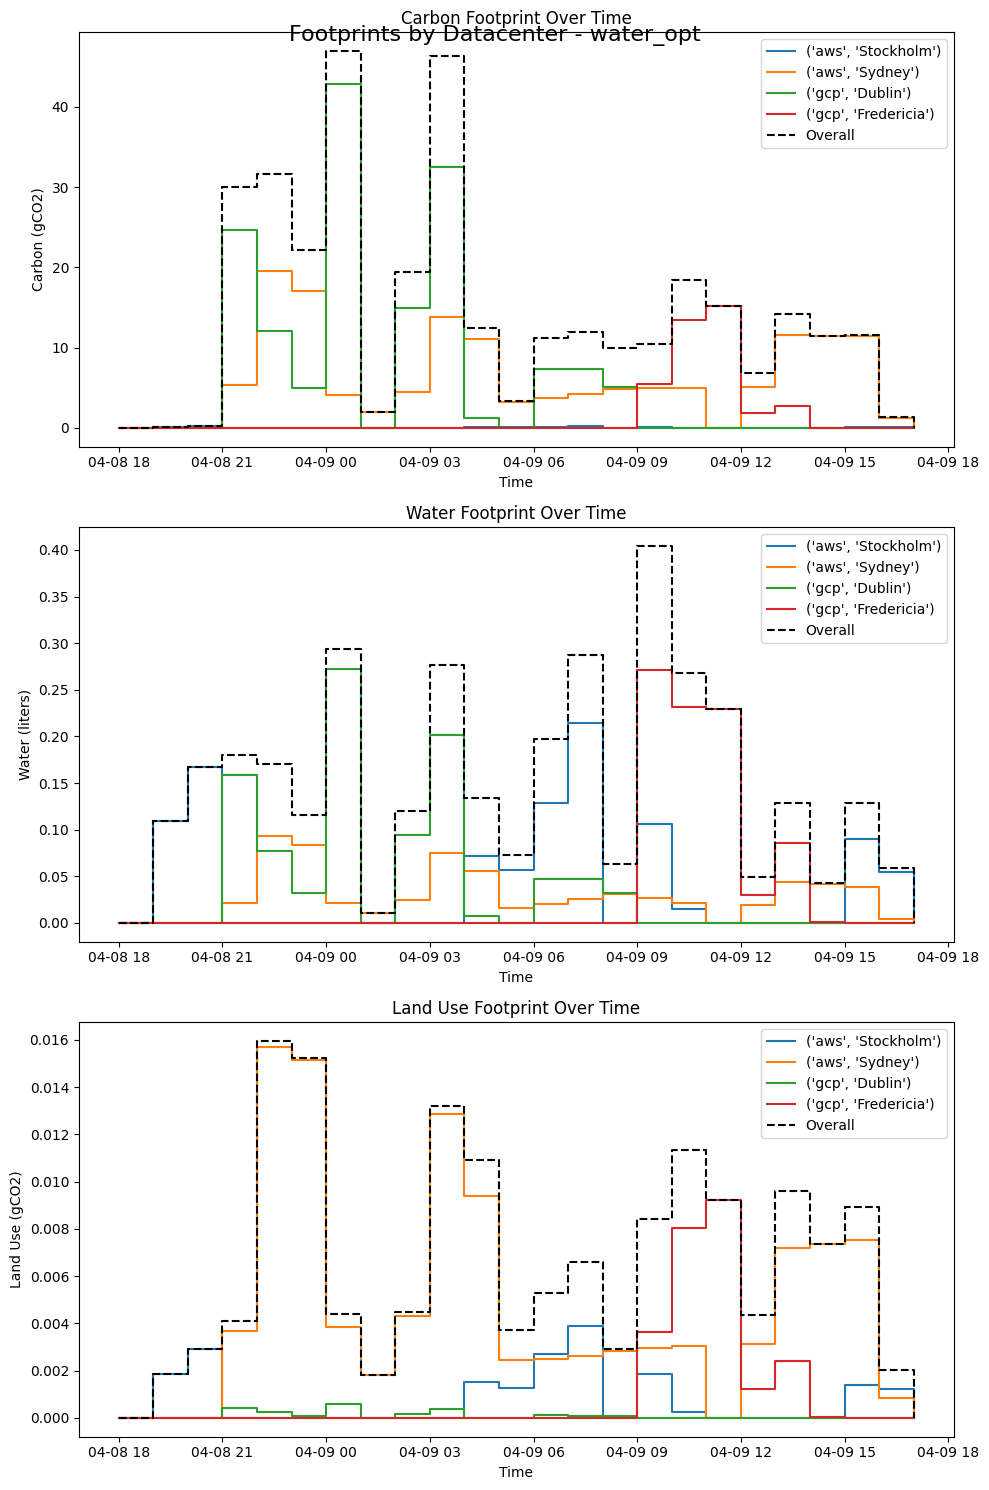

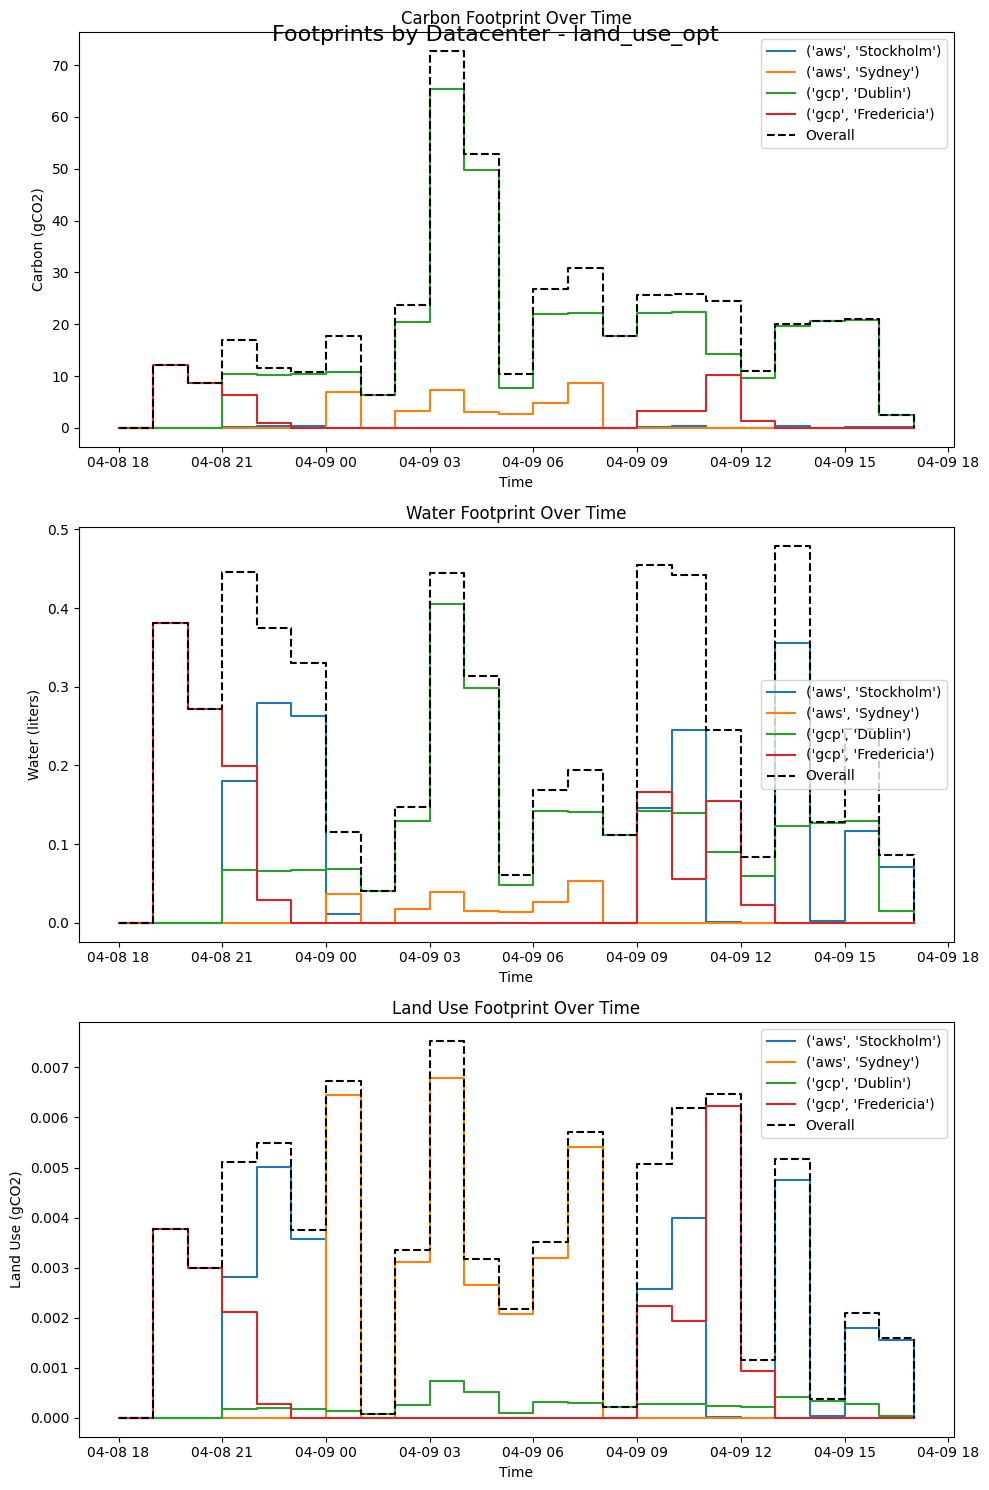

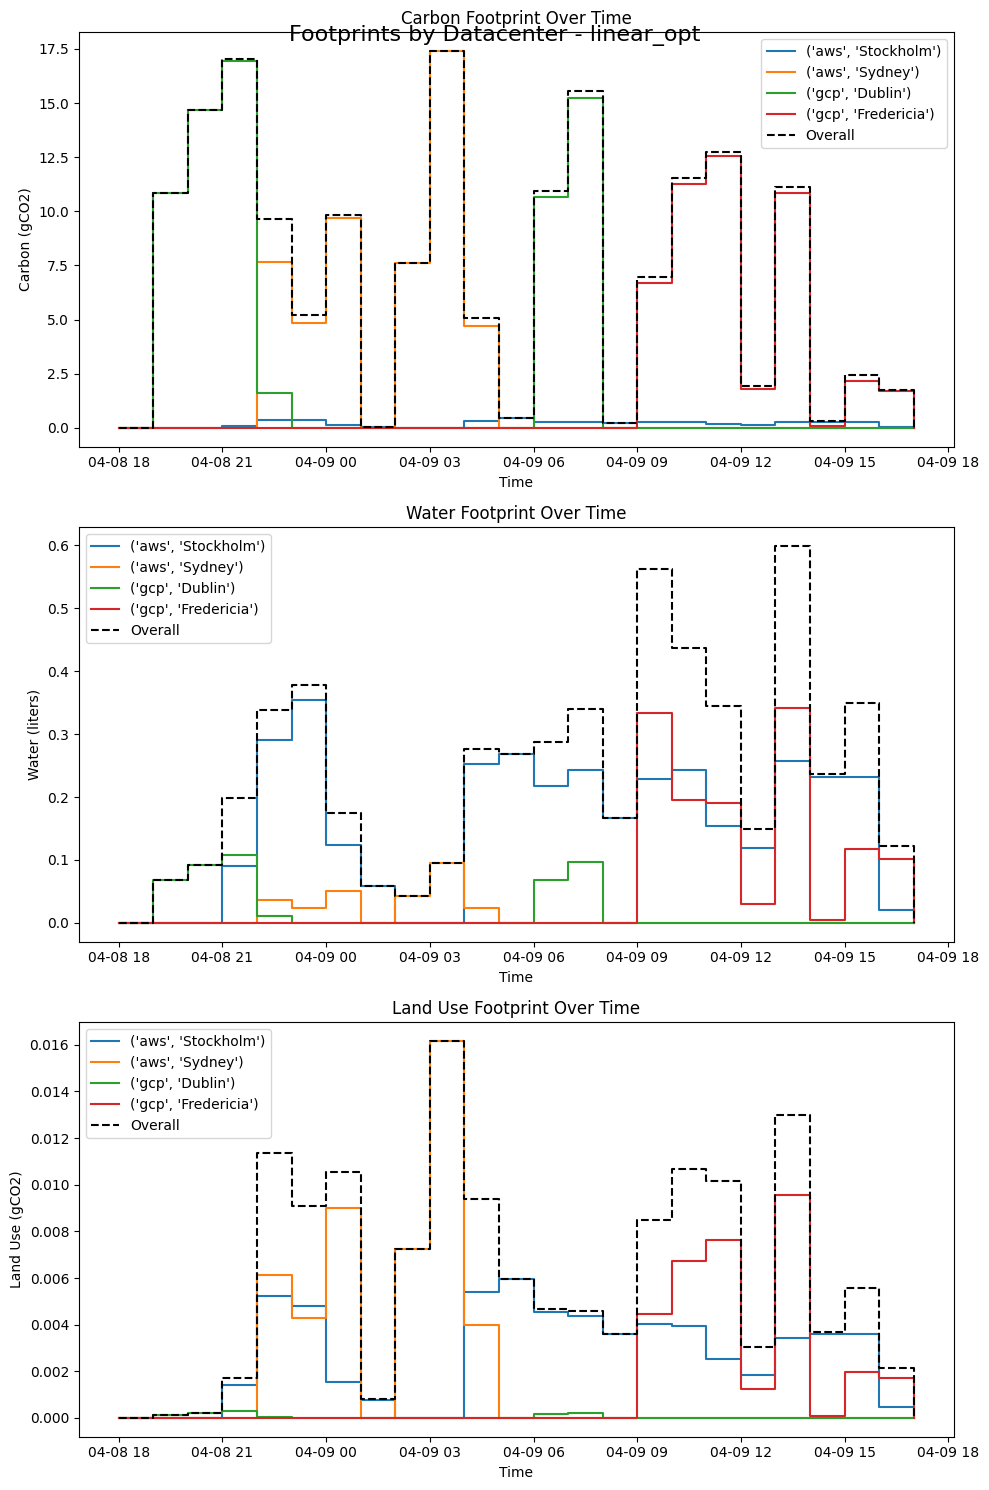

In [12]:
out_path = f"out/{config.d_i}-{config.d_f}"
import os
if not os.path.exists(out_path):
    os.makedirs(out_path)

from plot.src.plotter import plot_single_algorithm
for algo_name, footprint in footprints.items():
    utils.save_output(out_path=out_path, footprints=footprint, algo_name=algo_name)
    plot_single_algorithm(footprints=footprint, timestamps=timestamps, out_path=out_path, algorithm_name=algo_name)


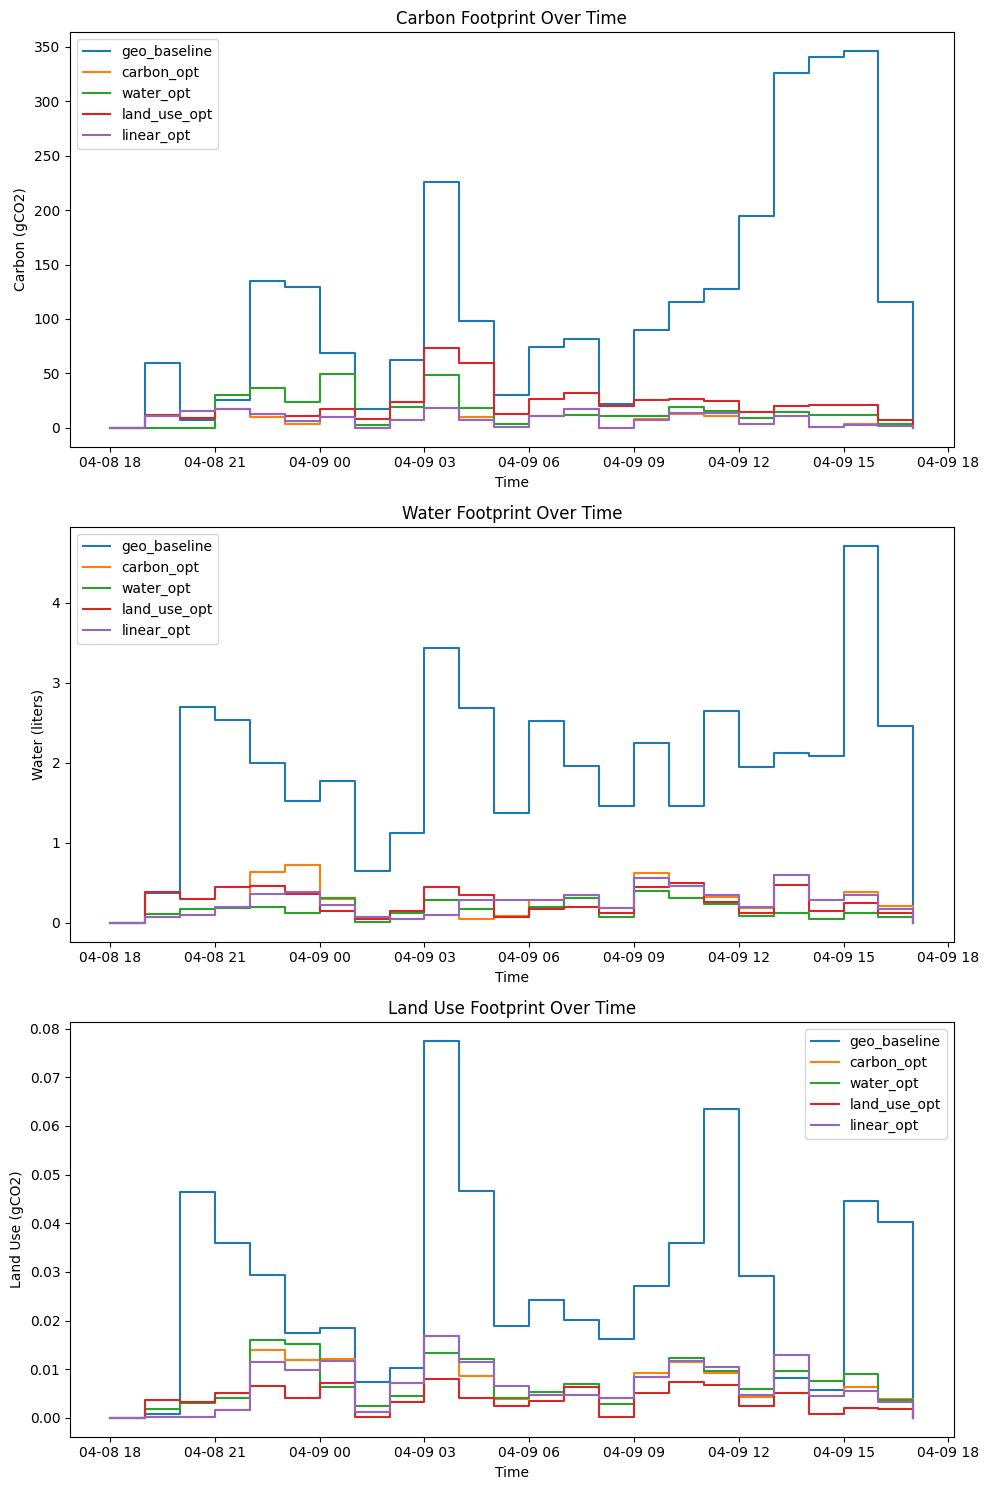

In [13]:
from plot.src.plotter import plot_algorithms_comparison
plot_algorithms_comparison(footprints=footprints, timestamps=timestamps, out_path=out_path)